In [108]:
import h5py as h5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [109]:
# data_dict['K562'] = h5py.File(self.data_folder + '/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5', 'r')
# self.data_dict['GM12878'] = h5py.File(self.data_folder + '/GM12878_DNase_ENCFF020WZB_2kb_4DNFI1UEG1HD_promoter_enhancer_encoding.h5', 'r')
data_h5 = h5.File('../data/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5', 'r')

In [110]:
data_h5.keys()

<KeysViewHDF5 ['activity', 'distance', 'ensid', 'hic', 'pe_code']>

In [125]:
idx = 100
sample_ensid = data_h5['ensid'][idx].decode()
sample_ensid

'ENSG00000005513'

In [126]:
enhancer_intensity = data_h5['activity'][idx,1:]
enhancer_intensity

array([0.212398, 0.262438, 0.237029, 6.06713 , 1.051706, 0.150271,
       0.583098, 0.307499, 0.524444, 0.270791, 0.386226, 0.248012,
       0.334427, 0.279128, 0.32579 , 0.493826, 0.260607, 0.127631,
       0.287463, 0.207245, 0.221224, 0.297277, 0.204524, 0.312753,
       0.289241, 0.232839, 0.318156, 0.112687, 0.351051, 0.143523,
       0.272057, 0.167365, 0.297542, 0.347299, 0.395042, 0.562525,
       0.174737, 0.291795, 0.318281, 0.320304, 0.398554, 0.436749,
       0.123629, 0.227371, 0.376045, 0.23425 , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ])

In [127]:
#enhancer_preds = pd.read_csv('../data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/Gene-enhancer links/EnhancerPredictions.txt', sep='\t')
enhancer_preds = pd.read_csv('../data/K562_enhancer_gene_links_100kb.tsv', sep='\t')
enhancer_preds = enhancer_preds.rename(columns={'#chr': 'chr'})
enhancer_preds

,index,chr,start,end,name,class,activity_base,normalized_h3K27ac,normalized_dhs,activity_base_squared,...,hic_contact_pl_scaled,hic_pseudocount,hic_contact_pl_scaled_adj,ABC.Score.Numerator,ABC.Score,powerlaw.Score.Numerator,powerlaw.Score,CellType,hic_contact_squared,Ensembl_ID
0,0,chr11,131670,132170,promoter|chr11:131670-132170,promoter,0.120023,0.203454,0.070805,0.014406,...,0.362636,0.0,0.362636,0.043525,0.012493,0.001397,0.000034,K562_ID_2644,0.131505,ENSG00000177951
1,1,chr11,192829,193329,promoter|chr11:192829-193329,promoter,0.120023,0.203454,0.070805,0.014406,...,0.016613,0.0,0.016613,0.001994,0.000572,0.005924,0.000145,K562_ID_2644,0.000276,ENSG00000177951
2,2,chr11,196510,197010,promoter|chr11:196510-197010,promoter,0.120023,0.203454,0.070805,0.014406,...,0.015123,0.0,0.015123,0.001815,0.000521,0.007667,0.000187,K562_ID_2644,0.000229,ENSG00000177951
3,4,chr11,208306,209000,genic|chr11:208306-209000,genic,12.204280,16.490391,9.032196,148.944450,...,0.048342,0.0,0.048342,0.589974,0.169337,5.096856,0.124644,K562_ID_2644,0.002337,ENSG00000177951
4,5,chr11,209447,209947,genic|chr11:209447-209947,genic,1.264797,1.526782,1.047768,1.599711,...,0.048342,0.0,0.048342,0.061142,0.017549,0.309672,0.007573,K562_ID_2644,0.002337,ENSG00000177951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309398,9598449,chr12,133135686,133136186,genic|chr12:133135686-133136186,genic,0.713321,0.614170,0.828480,0.508827,...,0.094447,0.0,0.094447,0.067371,0.030555,0.083575,0.001382,K562_ID_2644,0.008920,ENSG00000256223
309399,9598450,chr12,133181136,133181658,promoter|chr12:133181136-133181658,promoter,5.371967,3.855963,7.484000,28.858029,...,0.014719,0.0,0.014719,0.079071,0.035861,0.088281,0.001460,K562_ID_2644,0.000217,ENSG00000256223
309400,9598716,chr12,133129899,133131181,promoter|chr12:133129899-133131181,promoter,14.266703,11.568626,17.594035,203.538814,...,0.014719,0.0,0.014719,0.209993,0.132311,0.234062,0.001839,K562_ID_2644,0.000217,ENSG00000090612
309401,9598717,chr12,133135686,133136186,genic|chr12:133135686-133136186,genic,0.713321,0.614170,0.828480,0.508827,...,0.004825,0.0,0.004825,0.003442,0.002169,0.012902,0.000101,K562_ID_2644,0.000023,ENSG00000090612


In [129]:
sample_info = enhancer_preds[enhancer_preds['Ensembl_ID'] == sample_ensid][['chr', 'start', 'end', 'name', 'TargetGeneTSS']]
sample_info

,chr,start,end,name,TargetGeneTSS
156709,chr16,890281,890781,genic|chr16:890281-890781,981807
156710,chr16,895318,895818,genic|chr16:895318-895818,981807
156711,chr16,918011,918511,genic|chr16:918011-918511,981807
156712,chr16,920782,921282,promoter|chr16:920782-921282,981807
156713,chr16,937661,938161,genic|chr16:937661-938161,981807
156714,chr16,951578,952157,genic|chr16:951578-952157,981807
156715,chr16,970461,971391,promoter|chr16:970461-971391,981807
156716,chr16,978453,978953,intergenic|chr16:978453-978953,981807
156717,chr16,997428,997928,intergenic|chr16:997428-997928,981807
156718,chr16,1002657,1003157,intergenic|chr16:1002657-1003157,981807


In [131]:
max_distance_down = 0
max_distance_up = 0
for i, row in sample_info.iterrows():
    down_distance = row['start'] - row['TargetGeneTSS']
    up_distance = row['TargetGeneTSS'] - row['end']
    if down_distance > max_distance_down:
        max_distance_down = down_distance
    if up_distance > max_distance_up:
        max_distance_up = up_distance
print(f'Max distance down: {max_distance_down}, Max distance up: {max_distance_up}')

Max distance down: 96674, Max distance up: 91026


In [132]:
enhancer_list = pd.read_csv("../data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/DNase_ENCFF257HEE_Neighborhoods/EnhancerList.txt", sep='\t')
enhancer_list = enhancer_list[['chr', 'start', 'end', 'name', 'activity_base', 'activity_base_no_qnorm']]
enhancer_list

,chr,start,end,name,activity_base,activity_base_no_qnorm
0,chr1,585952,586452,intergenic|chr1:585952-586452,0.088073,0.088073
1,chr1,605341,605841,intergenic|chr1:605341-605841,0.355894,0.355894
2,chr1,629686,630186,intergenic|chr1:629686-630186,0.690581,0.690581
3,chr1,633778,634278,intergenic|chr1:633778-634278,1.575716,1.575716
4,chr1,778388,779144,intergenic|chr1:778388-779144,8.205368,8.205368
...,...,...,...,...,...,...
116664,chrY,11329663,11330163,intergenic|chrY:11329663-11330163,0.931987,0.931987
116665,chrY,11333773,11334507,intergenic|chrY:11333773-11334507,0.434642,0.434642
116666,chrY,11712120,11712620,intergenic|chrY:11712120-11712620,0.044362,0.044362
116667,chrY,56849825,56850381,intergenic|chrY:56849825-56850381,0.406223,0.406223


In [133]:
region_names = set(sample_info['name'].values)

enhancer_list_sample = enhancer_list[enhancer_list['name'].isin(region_names)]
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm


In [118]:
sample_match = []
for i, row in enhancer_list_sample.iterrows():
    # check if value appears anywhere in the enhancer_intensity
    if row['activity_base'] in enhancer_intensity:
        # check if it has already been matched
        if row['activity_base'] in sample_match:
            print(f"Duplicate match found for {row['activity_base']}")
            sample_match.append(np.nan)
        if row['activity_base'] not in sample_match:
            sample_match.append(row['activity_base'])
    else:
        sample_match.append(np.nan)

enhancer_list_sample['known_activity'] = sample_match
enhancer_list_sample['used'] = enhancer_list_sample['known_activity'].notna()
enhancer_list_sample

/tmp/ipykernel_3409528/1779143456.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enhancer_list_sample['known_activity'] = sample_match
/tmp/ipykernel_3409528/1779143456.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enhancer_list_sample['used'] = enhancer_list_sample['known_activity'].notna()


,chr,start,end,name,activity_base,activity_base_no_qnorm,known_activity,used
30975,chr4,111642023,111642523,intergenic|chr4:111642023-111642523,0.149696,0.149696,NaN,False
30976,chr4,112031609,112032109,intergenic|chr4:112031609-112032109,0.259769,0.259769,NaN,False
30977,chr4,112060147,112060747,intergenic|chr4:112060147-112060747,0.190765,0.190765,NaN,False
30978,chr4,112075048,112075548,intergenic|chr4:112075048-112075548,0.567808,0.567808,NaN,False
30979,chr4,112085844,112086492,intergenic|chr4:112085844-112086492,0.671588,0.671588,NaN,False
30980,chr4,112099599,112100099,intergenic|chr4:112099599-112100099,0.383245,0.383245,NaN,False
30982,chr4,112153116,112153935,genic|chr4:112153116-112153935,1.954451,1.954451,1.954451,True
30983,chr4,112170320,112170820,genic|chr4:112170320-112170820,2.645055,2.645055,2.645055,True
30984,chr4,112214651,112215151,intergenic|chr4:112214651-112215151,0.388502,0.388502,0.388502,True
30986,chr4,112234912,112235412,genic|chr4:112234912-112235412,0.629570,0.629570,0.629570,True


In [119]:
sample_tss = enhancer_preds[enhancer_preds['TargetGene'] == sample_ensid]['TargetGeneTSS'].values[0]
distance_to_tss = []
for i, row in enhancer_list_sample.iterrows():
    if sample_tss > row['start']:
        distance = row['end'] - sample_tss
    else:
        distance = row['start'] - sample_tss
    distance_to_tss.append(distance)

enhancer_list_sample['distance_to_tss'] = distance_to_tss
enhancer_list_sample

/tmp/ipykernel_3409528/136517399.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enhancer_list_sample['distance_to_tss'] = distance_to_tss


,chr,start,end,name,activity_base,activity_base_no_qnorm,known_activity,used,distance_to_tss
30975,chr4,111642023,111642523,intergenic|chr4:111642023-111642523,0.149696,0.149696,NaN,False,-654877
30976,chr4,112031609,112032109,intergenic|chr4:112031609-112032109,0.259769,0.259769,NaN,False,-265291
30977,chr4,112060147,112060747,intergenic|chr4:112060147-112060747,0.190765,0.190765,NaN,False,-236653
30978,chr4,112075048,112075548,intergenic|chr4:112075048-112075548,0.567808,0.567808,NaN,False,-221852
30979,chr4,112085844,112086492,intergenic|chr4:112085844-112086492,0.671588,0.671588,NaN,False,-210908
30980,chr4,112099599,112100099,intergenic|chr4:112099599-112100099,0.383245,0.383245,NaN,False,-197301
30982,chr4,112153116,112153935,genic|chr4:112153116-112153935,1.954451,1.954451,1.954451,True,-143465
30983,chr4,112170320,112170820,genic|chr4:112170320-112170820,2.645055,2.645055,2.645055,True,-126580
30984,chr4,112214651,112215151,intergenic|chr4:112214651-112215151,0.388502,0.388502,0.388502,True,-82249
30986,chr4,112234912,112235412,genic|chr4:112234912-112235412,0.629570,0.629570,0.629570,True,-61988


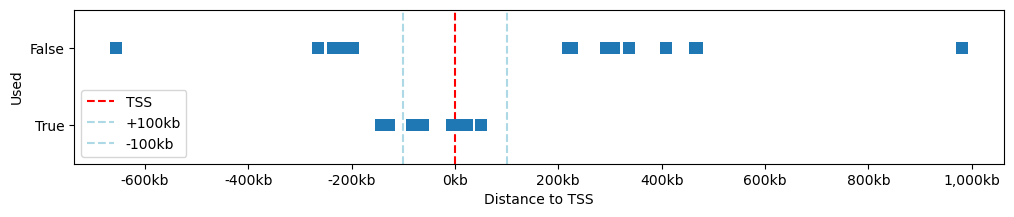

In [120]:
fig, ax = plt.subplots(figsize=(12, 2))
sns.stripplot(data=enhancer_list_sample, x='distance_to_tss', y='used', ax=ax, jitter=False, size=8, marker='s', orient='h')
# vertical line at 0
ax.axvline(x=0, color='red', linestyle='--', label='TSS')
ax.axvline(x=100_000, color='lightblue', linestyle='--', label='+100kb')
ax.axvline(x=-100_000, color='lightblue', linestyle='--', label='-100kb')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: '{:,.0f}'.format(y/1000) + 'kb'))
ax.set_xlabel('Distance to TSS')
ax.set_ylabel('Used')
ax.legend()
plt.show()